In [ ]:
# ==========================================================
# CONECTAR GOOGLE DRIVE
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ==========================================================
# IMPORTACION DE LIBRERIAS
# ==========================================================

# Numpy se utiliza para realizar operaciones matemáticas
# eficientes sobre arreglos y matrices.
import numpy as np

# Pandas se utiliza para cargar y manipular el dataset.
import pandas as pd

# Matplotlib se utiliza para generar gráficos.
import matplotlib.pyplot as plt

# Permite dividir el dataset en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Permite normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Permite convertir variables categóricas en numéricas
from sklearn.preprocessing import LabelEncoder

In [7]:
# ==========================================================
# CARGA DEL DATASET
# ==========================================================

# Se carga el dataset Census Income KDD desde Google Drive.
# Este dataset contiene más de 199000 registros y más de 40
# propiedades, cumpliendo con los requisitos del ejercicio.

data = pd.read_csv(
    "/content/drive/MyDrive/data sets /Census Income KDD Dataset/census-income.data",
    header=None
)

print("Dimensiones del dataset:")
print(data.shape)

data.head()

Dimensiones del dataset:
(199523, 42)


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [8]:
# ==========================================================
# ANALISIS DEL DATASET
# ==========================================================

# Se observa información general del dataset
print(data.info())

# Se muestran estadísticas básicas
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       199523 non-null  int64  
 1   1       199523 non-null  object 
 2   2       199523 non-null  int64  
 3   3       199523 non-null  int64  
 4   4       199523 non-null  object 
 5   5       199523 non-null  int64  
 6   6       199523 non-null  object 
 7   7       199523 non-null  object 
 8   8       199523 non-null  object 
 9   9       199523 non-null  object 
 10  10      199523 non-null  object 
 11  11      199523 non-null  object 
 12  12      199523 non-null  object 
 13  13      199523 non-null  object 
 14  14      199523 non-null  object 
 15  15      199523 non-null  object 
 16  16      199523 non-null  int64  
 17  17      199523 non-null  int64  
 18  18      199523 non-null  int64  
 19  19      199523 non-null  object 
 20  20      199523 non-null  object 
 21  21      19

In [9]:
# ==========================================================
# SEPARACION DE VARIABLES
# ==========================================================

# Se separan las variables independientes (X)
# y la variable objetivo (y).

X = data.iloc[:,0:40]

# la columna 41 contiene la clase
y = data.iloc[:,41]

print("Variables de entrada:", X.shape)
print("Variable objetivo:", y.shape)

Variables de entrada: (199523, 40)
Variable objetivo: (199523,)


In [10]:
# ==========================================================
# CODIFICACION DE VARIABLES CATEGORICAS
# ==========================================================

# Muchos algoritmos de Machine Learning requieren datos
# numéricos. Por lo tanto, se convierten las variables
# categóricas en valores numéricos utilizando LabelEncoder.

label = LabelEncoder()

for column in X.columns:
    X[column] = label.fit_transform(X[column].astype(str))

# convertir variable objetivo
y = label.fit_transform(y.astype(str))

In [11]:
# ==========================================================
# NORMALIZACION DE DATOS
# ==========================================================

# La normalización permite que todas las variables tengan
# una escala similar, mejorando el proceso de entrenamiento.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
# ==========================================================
# DIVISION DE DATOS
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

Datos entrenamiento: (159618, 40)
Datos prueba: (39905, 40)


In [13]:
# ==========================================================
# FUNCION SIGMOIDE
# ==========================================================

def sigmoid(z):

    return 1 / (1 + np.exp(-z))

In [14]:
# ==========================================================
# FUNCION DE COSTO
# ==========================================================

def cost_function(X, y, theta):

    m = len(y)

    h = sigmoid(np.dot(X, theta))

    cost = (-1/m) * np.sum(
        y*np.log(h) + (1-y)*np.log(1-h)
    )

    return cost

In [15]:
# ==========================================================
# GRADIENTE DESCENDENTE
# ==========================================================

def gradient_descent(X, y, theta, alpha, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        h = sigmoid(np.dot(X,theta))

        gradient = (1/m) * np.dot(X.T,(h-y))

        theta = theta - alpha * gradient

        cost = cost_function(X,y,theta)

        cost_history.append(cost)

    return theta, cost_history

In [16]:
# ==========================================================
# ENTRENAMIENTO DEL MODELO
# ==========================================================

# agregar columna de 1 para intercepto
X_train = np.c_[np.ones(X_train.shape[0]), X_train]

theta = np.zeros(X_train.shape[1])

theta, cost_history = gradient_descent(
    X_train,
    y_train,
    theta,
    0.01,
    1000
)

print("Theta final:")
print(theta)

Theta final:
[-1.88318595e+00  5.94454167e-02  2.54445948e-02  6.15637223e-02
  1.01055855e-02  5.52007027e-02 -6.41818182e-02  4.93248978e-02
 -5.23467612e-02 -2.61365797e-02  4.26103653e-02  2.48448660e-02
 -4.57882057e-02  1.60526910e-01 -1.85362450e-02 -2.86332726e-03
 -2.20851061e-02  1.35162791e-01  1.22477185e-01  1.72658904e-01
 -5.94148465e-02  3.65945681e-03  7.18451451e-03 -1.10633546e-02
  1.34719049e-04 -1.21627362e-02 -6.21382151e-03 -1.24971908e-02
 -1.14925953e-02  1.89267928e-02 -1.06556088e-02  1.20251851e-01
  1.98352138e-02 -1.27395766e-02 -9.20707037e-03 -2.98614638e-03
  1.41547246e-02 -9.44002794e-03 -2.00935716e-02  1.66286599e-02
  1.43571333e-01]


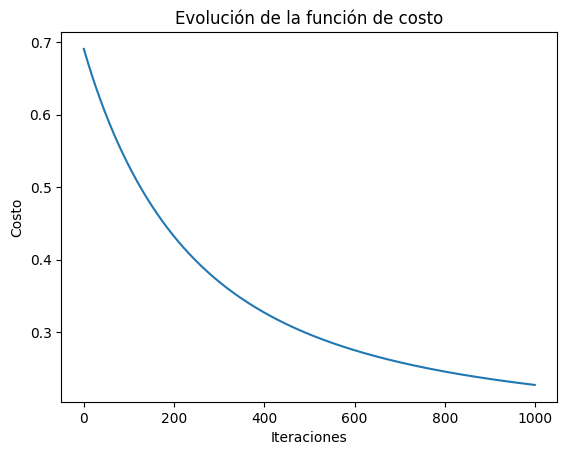

In [17]:
# ==========================================================
# GRAFICA DE COSTO
# ==========================================================

plt.plot(cost_history)

plt.title("Evolución de la función de costo")

plt.xlabel("Iteraciones")

plt.ylabel("Costo")

plt.show()

In [18]:
# ==========================================================
# PREDICCIONES
# ==========================================================

def predict(X,theta):

    prob = sigmoid(np.dot(X,theta))

    return prob >= 0.5

In [19]:
# ==========================================================
# EVALUACION DEL MODELO
# ==========================================================

X_test = np.c_[np.ones(X_test.shape[0]), X_test]

pred = predict(X_test,theta)

accuracy = np.mean(pred == y_test)

print("Precisión del modelo:",accuracy)

Precisión del modelo: 0.9431399573988222
